In [3]:
import pandas as pd     
import numpy as np     
import matplotlib.pyplot as plt 
import seaborn as sns  
print("Tools ready ")

Tools ready 


In [4]:

df = pd.read_csv("dailyActivity_merged.csv")


df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [5]:

df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])


print(f"Duplicates count: {df.duplicated().sum()}")


print("Missing values in each column:")
print(df.isnull().sum())

Duplicates count: 0
Missing values in each column:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64


In [6]:

df.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276672,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000
std,2.424805e+09,NaN,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862


In [7]:

def activity_level(steps):
    if steps < 5000:
        return "Sedentary"
    elif steps < 7500:
        return "Lightly Active"
    elif steps < 10000:
        return "Fairly Active"
    else:
        return "Very Active"


df['UserType'] = df['TotalSteps'].apply(activity_level)


df['UserType'].value_counts()

UserType
Very Active       303
Sedentary         303
Lightly Active    171
Fairly Active     163
Name: count, dtype: int64

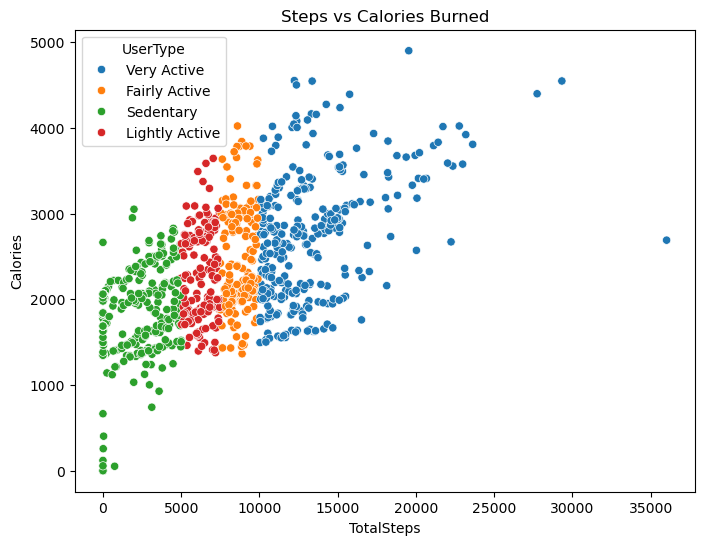

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='TotalSteps', y='Calories', hue='UserType')
plt.title('Steps vs Calories Burned')
plt.show()

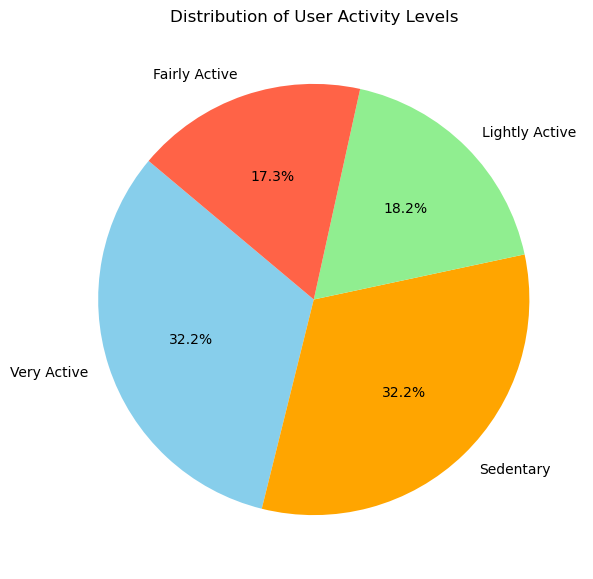

In [10]:
# User type distribution (Pie Chart)
plt.figure(figsize=(7,7))
df['UserType'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=['skyblue', 'orange', 'lightgreen', 'tomato'])
plt.title('Distribution of User Activity Levels')
plt.ylabel('') 
plt.show()

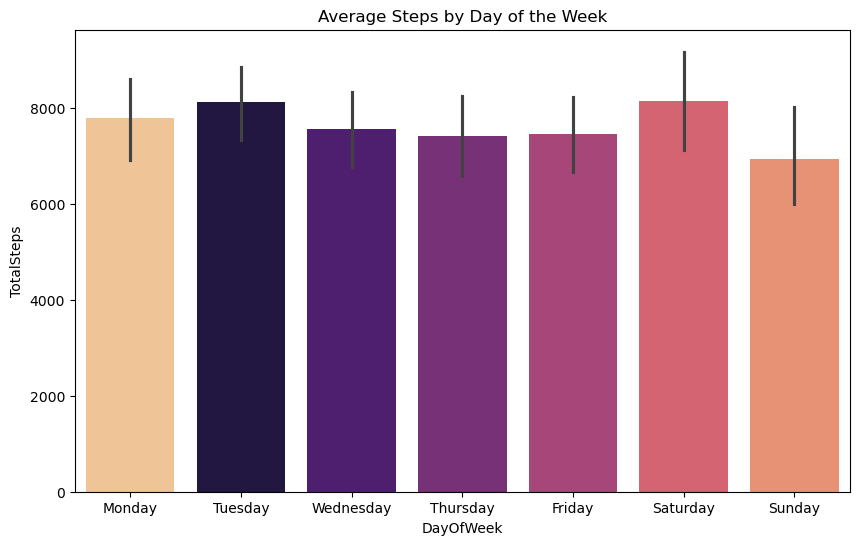

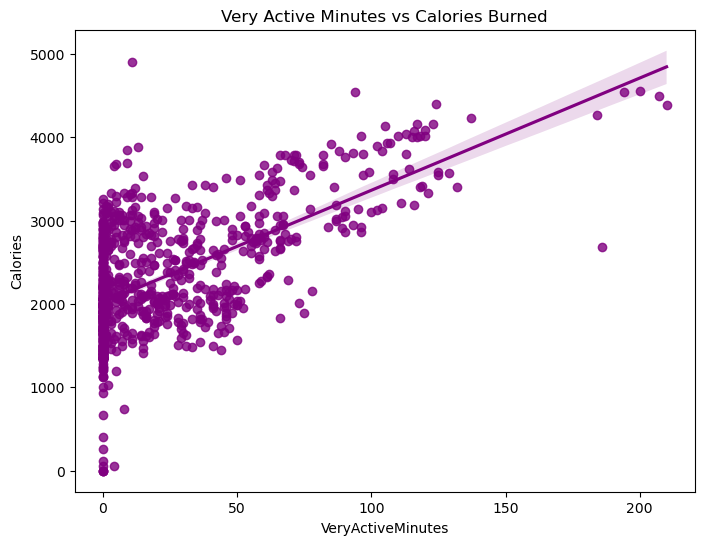

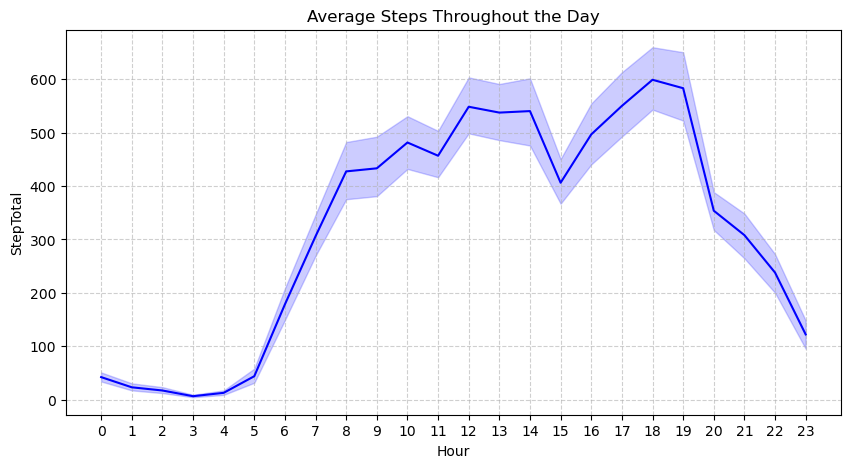

In [18]:

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='DayOfWeek', y='TotalSteps', order=days_order, palette='magma', hue='DayOfWeek', legend=False)
plt.title('Average Steps by Day of the Week')
plt.show()

plt.figure(figsize=(8,6))
sns.regplot(data=df, x='VeryActiveMinutes', y='Calories', color='purple')
plt.title('Very Active Minutes vs Calories Burned')
plt.show()

# Format-ah correct-ah specify panrom
hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'], format='%m/%d/%Y %I:%M:%S %p')

# Hour-ah extract panrom
hourly_steps['Hour'] = hourly_steps['ActivityHour'].dt.hour

# Graph: Average steps per hour
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_steps, x='Hour', y='StepTotal', color='blue')
plt.title('Average Steps Throughout the Day')
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

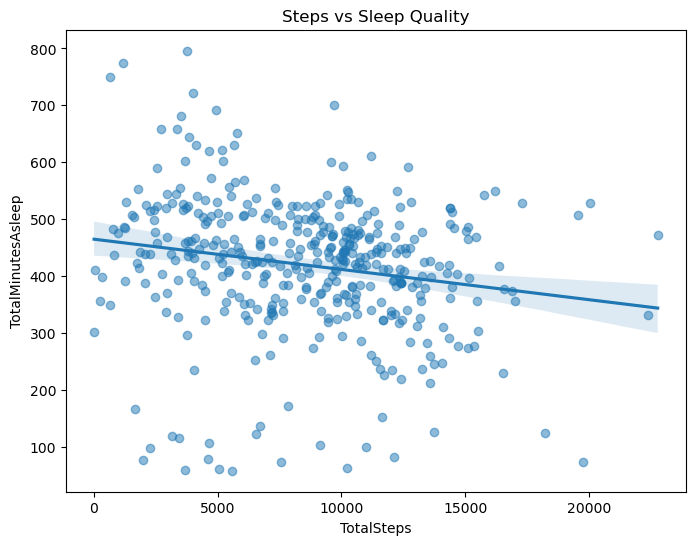

In [16]:
# Format specify panni date-ah mathurom (Error varaathu)
sleep_df['SleepDay'] = pd.to_datetime(sleep_df['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')

# Ippo merge panni graph podunga
combined_df = pd.merge(df, sleep_df, left_on=['Id', 'ActivityDate'], right_on=['Id', 'SleepDay'])

plt.figure(figsize=(8,6))
sns.regplot(data=combined_df, x='TotalSteps', y='TotalMinutesAsleep', scatter_kws={'alpha':0.5})
plt.title('Steps vs Sleep Quality')
plt.show()